<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Forecasting_time_series_data_freecodecamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
#!pip install statsforecast utilsforecast

### Import libraries


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

###Initial Setup

In [21]:
df = pd.read_csv("/content/sample_data/daily_sales_french_bakery.csv", parse_dates=["ds"])
df.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


In [22]:
df.shape

(57046, 4)

In [23]:
df.describe()

,ds,y,unit_price
count,57046,57046.000000,57046.000000
mean,2021-11-18 13:24:30.770956544,9.792814,3.631011
min,2021-01-02 00:00:00,0.000000,0.000000
25%,2021-06-25 00:00:00,0.000000,1.400000
50%,2021-11-17 00:00:00,0.900000,2.000000
75%,2022-04-17 00:00:00,8.000000,4.500000
max,2022-09-30 00:00:00,919.100000,60.000000
std,NaN,32.327068,3.909706


In [24]:
df = df.drop(columns= "unit_price",errors = "ignore")

In [25]:
df["unique_id"].value_counts()

,count
unique_id,
BAGUETTE,637
BOULE 200G,637
BANETTE,637
BANETTINE,637
BRIOCHE,637
...,...
PLAT 6.50E,1
SACHET DE VIENNOISERIE,1
TARTELETTE COCKTAIL,1


In [26]:
df["ds"] = pd.to_datetime(df["ds"])

print("Start date:", df["ds"].min())
print("End date:", df["ds"].max())

Start date: 2021-01-02 00:00:00
End date: 2022-09-30 00:00:00


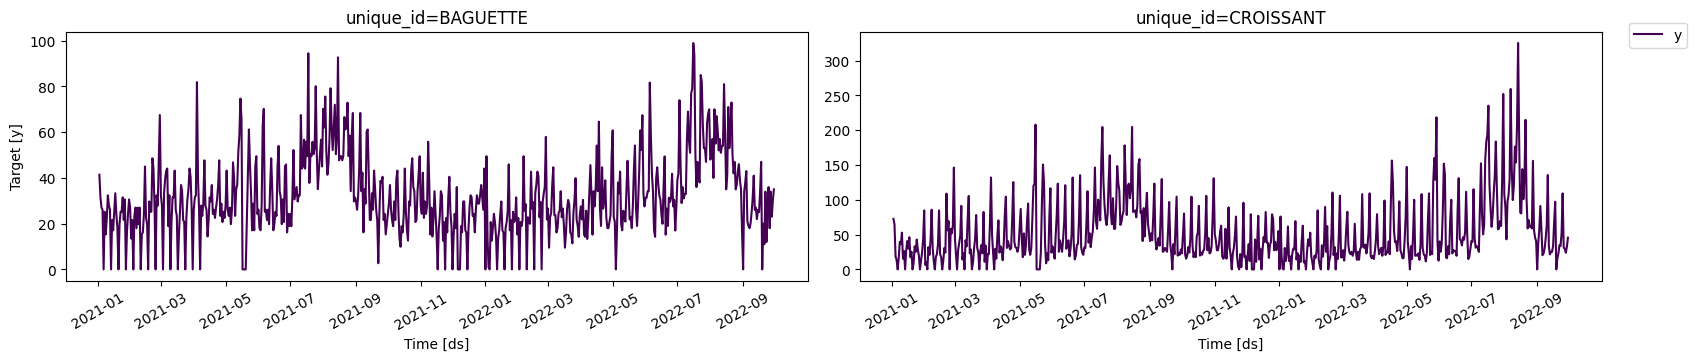

In [27]:
plot_series(df = df, ids = ["BAGUETTE","CROISSANT"], palette="viridis")

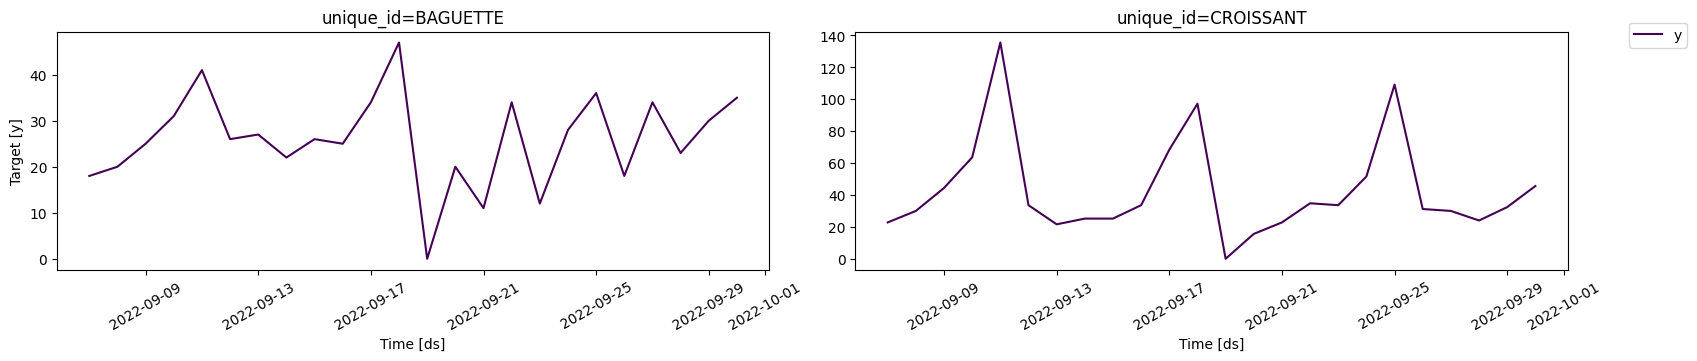

In [28]:
plot_series(df = df, ids = ["BAGUETTE","CROISSANT"],max_insample_length= 24, palette="viridis")

###Baseline Model

In [29]:
from statsforecast import StatsForecast
from statsforecast.models import Naive,HistoricAverage,WindowAverage,SeasonalNaive

In [30]:
horizon = 7 #We have daily dataset, nice to forecast nextweek data, so 7

models = [
    Naive(), # simply forecast the last time known timestep
    HistoricAverage(), #take the average of the entire history of our series ,the use the value as a forecast
    WindowAverage(window_size= 7),  #how many timesteps do you want to take into account to calculate that average? and forecast that value.
                                    #window_size = 7 means, take average of the last seven days and forecast that into future
    SeasonalNaive(season_length=7),
]

sf = StatsForecast(models = models, freq = "D") #freqency of the data---daily for D
sf.fit(df=df)

preds = sf.predict(h = horizon)

In [31]:
preds.head(7)

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0
5,12 MACARON,2022-10-04,10.0,8.974359,2.857143,0.0
6,12 MACARON,2022-10-05,10.0,8.974359,2.857143,10.0


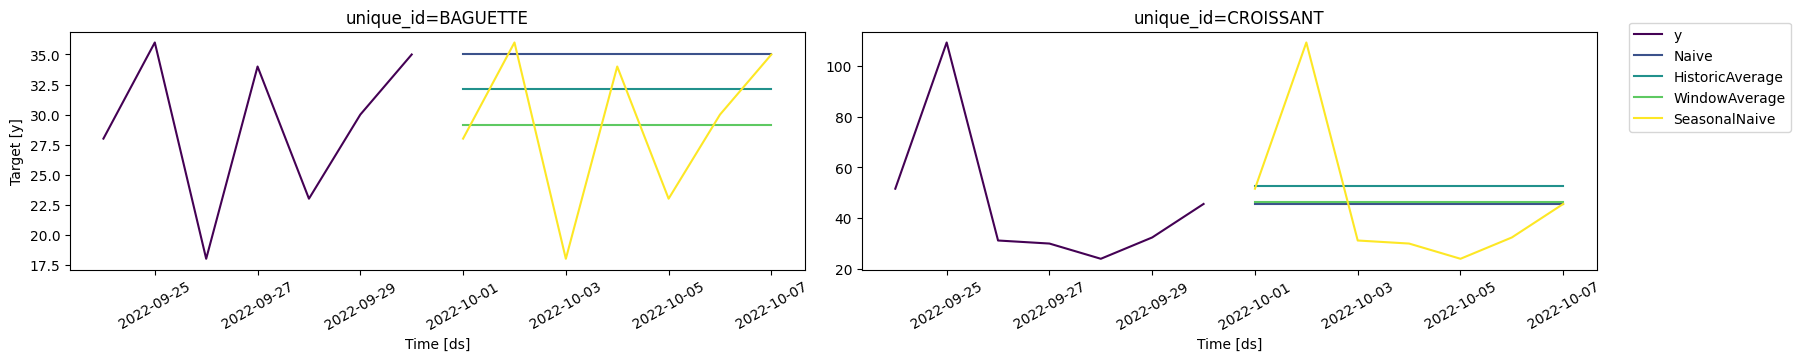

In [32]:
plot_series(
    df =df,
    forecasts_df= preds,
    ids = ["BAGUETTE","CROISSANT"],
    max_insample_length= 7,
    palette = "viridis"
)

###Evaluate baseline models

In [33]:
test = df.groupby("unique_id").tail(17)
train = df.drop(test.index).reset_index(drop = True)

In [34]:
sf.fit(df = train)
preds = sf.predict(h = horizon)
eval_df = pd.merge(test, preds,'left', ['ds', 'unique_id'])

In [35]:
evaluation = evaluate(
    eval_df,
    metrics= [mae],

)
evaluation.head(10)

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,8.571429,9.555035,5.510204,4.285714
1,ARMORICAIN,mae,NaN,NaN,NaN,NaN
2,ARTICLE 295,mae,NaN,NaN,NaN,NaN
3,BAGUETTE,mae,9.857143,12.142673,9.795918,7.428571
4,BAGUETTE APERO,mae,0.000000,0.539293,0.000000,0.000000
5,BAGUETTE GRAINE,mae,1.200000,4.035272,1.914286,0.200000
6,BANETTE,mae,12.157143,14.073329,9.739796,11.664286
7,BANETTINE,mae,1.500000,1.163295,1.157143,1.300000
8,BOISSON 33CL,mae,3.214286,3.816574,3.153061,3.642857
9,BOTTEREAU,mae,7.357143,7.842857,NaN,5.200000


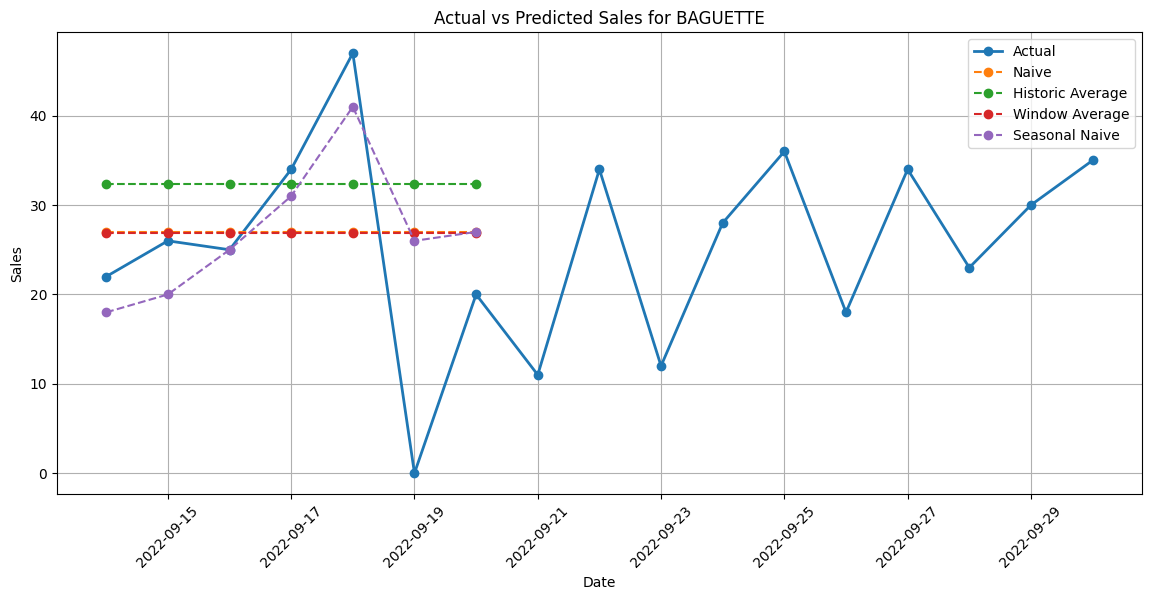

In [36]:

# Selecting one product
product_name = "BAGUETTE"

plot_df = eval_df[eval_df["unique_id"] == product_name].copy()

# Keeping only the 17 test rows
plot_df = plot_df.sort_values("ds").tail(17)

plt.figure(figsize=(14, 6))

# Actual values
plt.plot(
    plot_df["ds"],
    plot_df["y"],
    marker="o",
    linewidth=2,
    label="Actual"
)

# Model predictions
plt.plot(
    plot_df["ds"],
    plot_df["Naive"],
    marker="o",
    linestyle="--",
    label="Naive"
)

plt.plot(
    plot_df["ds"],
    plot_df["HistoricAverage"],
    marker="o",
    linestyle="--",
    label="Historic Average"
)

plt.plot(
    plot_df["ds"],
    plot_df["WindowAverage"],
    marker="o",
    linestyle="--",
    label="Window Average"
)

plt.plot(
    plot_df["ds"],
    plot_df["SeasonalNaive"],
    marker="o",
    linestyle="--",
    label="Seasonal Naive"
)

plt.title(f"Actual vs Predicted Sales for {product_name}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [37]:
evaluation = evaluation.drop(['unique_id'],axis = 1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,5.043543,5.559802,5.279111,4.4602


### Statistical Models
### ARIMA (Autoregressive Integrated Moving average)

#####AutoArima to find out the optimal parameter combination

In [38]:
from statsforecast.models import AutoARIMA

In [39]:
unique_ids = ["BAGUETTE", "CROISSANT"]

small_train = train[train["unique_id"].isin(unique_ids)]
small_test = test[test["unique_id"].isin(unique_ids)]

In [40]:
small_train = small_train.drop(columns=["unit_price"], errors='ignore')


In [41]:
print(f"Length of small_train: {small_train.shape[0]}")
print(f"Length of small_test: {small_test.shape[0]}")

Length of small_train: 1240
Length of small_test: 34


In [42]:
models = [
    AutoARIMA (seasonal= False,alias = "ARIMA"),
    AutoARIMA(season_length= 7, alias = "SARIMA")
]

In [43]:

sf = StatsForecast(models = models, freq = "D")
sf.fit(df = small_train)
arima_preds = sf.predict(h = horizon)

In [44]:
arima_eval_df = pd.merge(arima_preds,eval_df,'inner',['ds','unique_id'])

In [45]:
arima_eval = evaluate(arima_eval_df,
                      metrics = [mae],
                      )
arima_eval

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,BAGUETTE,mae,8.556240,6.400263,9.857143,12.142673,9.795918,7.428571
1,CROISSANT,mae,20.602166,21.528397,24.171429,32.169885,30.955102,14.400000


In [46]:
arima_eval = arima_eval.drop(['unique_id'],axis = 1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,14.579203,13.96433,17.014286,22.156279,20.37551,10.914286


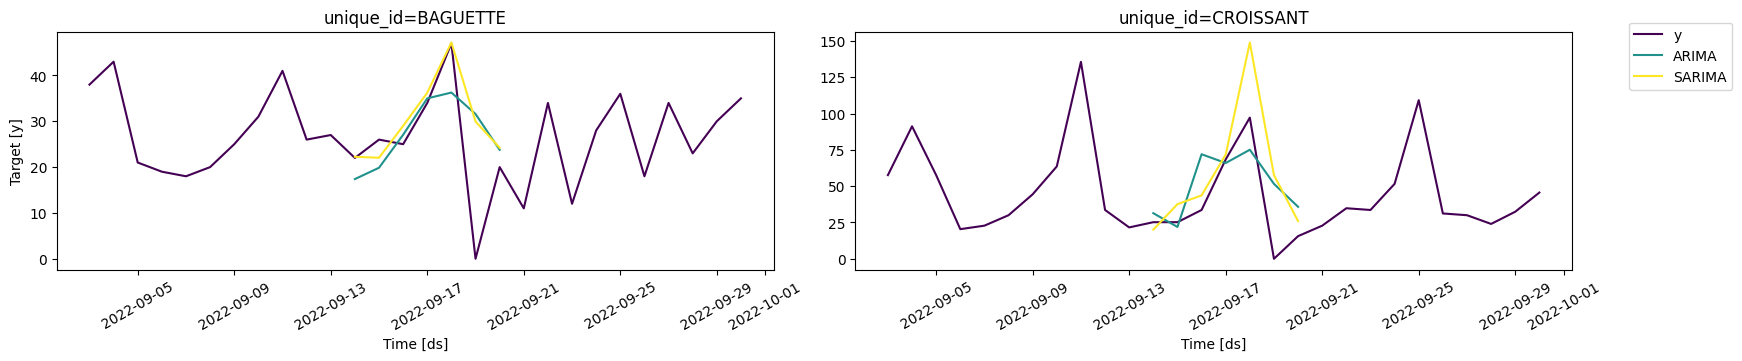

In [47]:
plot_series(
    df = df,
    forecasts_df= arima_preds,
    ids = ["BAGUETTE", "CROISSANT"],
    max_insample_length= 28,
    palette= "viridis"
    )

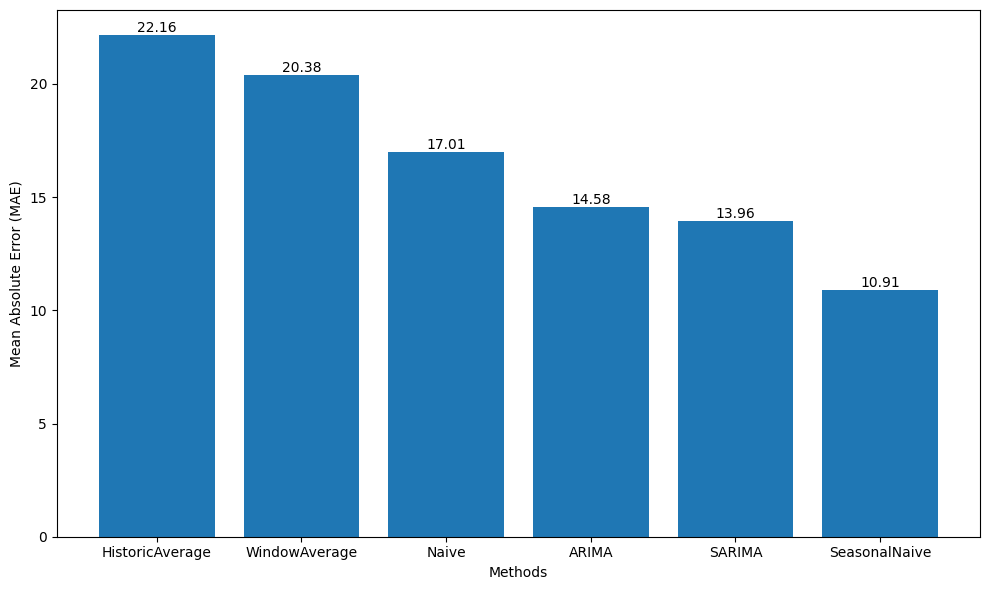

In [48]:
methods = arima_eval.columns[1:].tolist()
values = arima_eval.iloc[0,1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse = True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted,values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.2f}', ha='center', va='bottom')

plt.xlabel('Methods')
plt.ylabel('Mean Absolute Error (MAE)')
plt.tight_layout()

plt.show()


###Time-Series Cross-Validation

In [49]:
small_df = df[df["unique_id"].isin(unique_ids)]
small_df.head(5)

,unique_id,ds,y
84,BAGUETTE,2021-01-02,41.4
85,BAGUETTE,2021-01-03,31.5
86,BAGUETTE,2021-01-04,27.0
87,BAGUETTE,2021-01-05,26.1
88,BAGUETTE,2021-01-06,0.0


In [50]:
models = [
    SeasonalNaive(season_length= 7),
    AutoARIMA(season_length= 7, alias = "SARIMA"),
    AutoARIMA (seasonal= False,alias = "ARIMA"),
]

In [51]:
sf = StatsForecast(models = models,freq = "D")
cv_df = sf.cross_validation(
    h = horizon,
    df = small_df,
    n_windows = 8,
    step_size = horizon,
    refit = True
)

In [52]:
cv_df.head(7)

,unique_id,ds,cutoff,y,SeasonalNaive,SARIMA,ARIMA
0,BAGUETTE,2022-08-06,2022-08-05,55.0,68.0,71.584713,71.355196
1,BAGUETTE,2022-08-07,2022-08-05,67.0,70.0,78.458883,70.337980
2,BAGUETTE,2022-08-08,2022-08-05,61.0,48.0,57.001732,61.195004
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.0,49.401144,52.649013
4,BAGUETTE,2022-08-10,2022-08-05,57.0,57.0,49.725278,47.785876
5,BAGUETTE,2022-08-11,2022-08-05,51.0,40.0,48.316339,53.274424
6,BAGUETTE,2022-08-12,2022-08-05,54.0,70.0,56.860489,63.513710


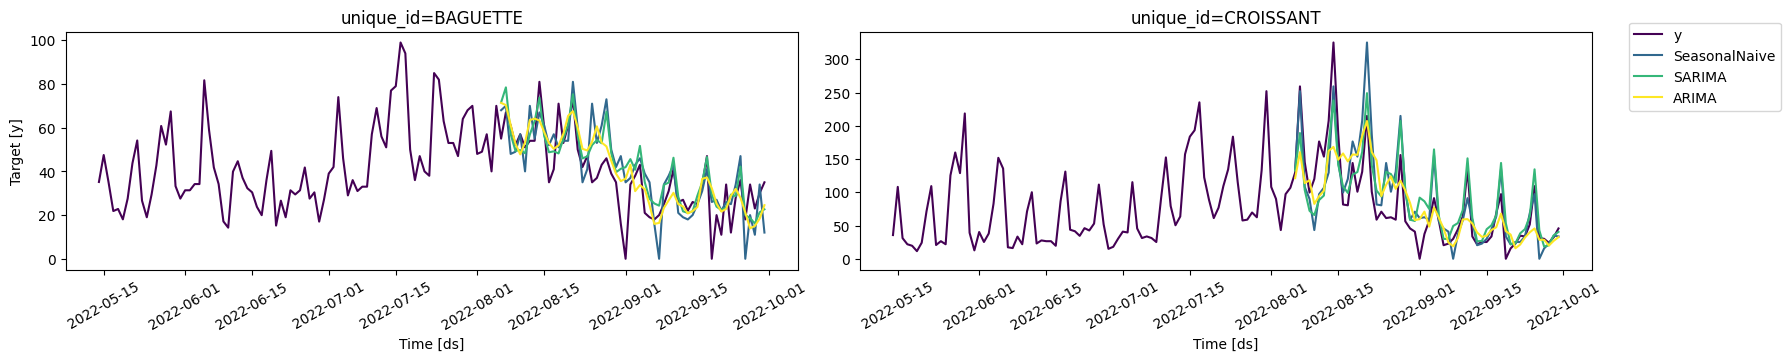

In [53]:
from matplotlib import axis
plot_series(
    df = small_df,
    forecasts_df= cv_df.drop(["y","cutoff"],axis=1),
    ids = ["BAGUETTE", "CROISSANT"],
    max_insample_length= 140,
    palette= "viridis"
    )

In [54]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"],axis=1),
    metrics = [mae],
)

cv_eval = cv_eval.drop(['unique_id'],axis = 1).groupby('metric').mean().reset_index()
cv_eval

,metric,SeasonalNaive,SARIMA,ARIMA
0,mae,21.117857,19.281296,21.17093


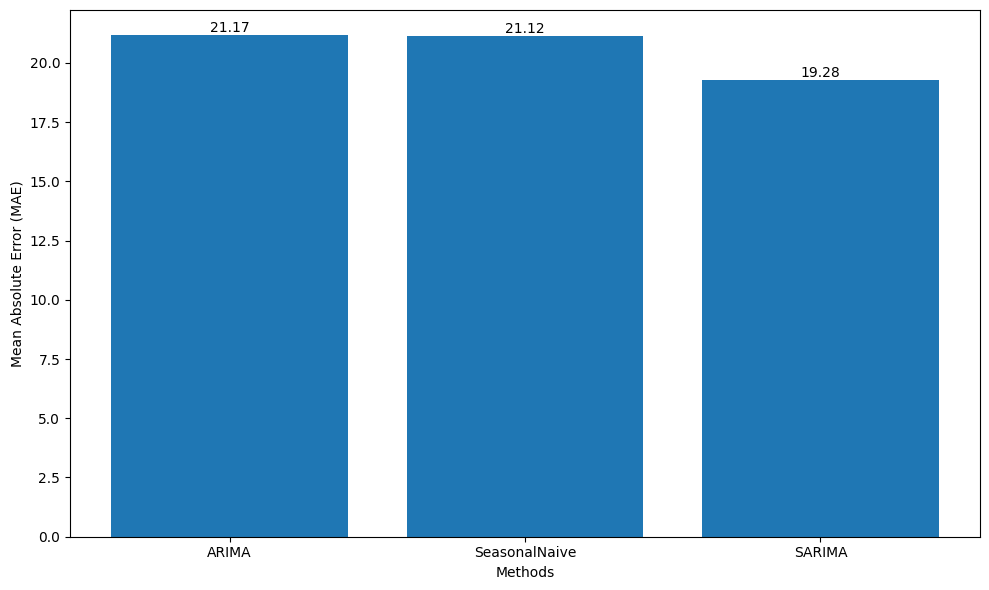

In [55]:
methods = cv_eval.columns[1:].tolist()
values = cv_eval.iloc[0,1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse = True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted,values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.2f}', ha='center', va='bottom')

plt.xlabel('Methods')
plt.ylabel('Mean Absolute Error (MAE)')
plt.tight_layout()

plt.show()

### Forecasting with Exogenous features

In [56]:
df1 = pd.read_csv("/content/sample_data/daily_sales_french_bakery.csv", parse_dates=["ds"])
df1 = df1.groupby("unique_id").filter(lambda x : len(x)>=28)
df1.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


In [57]:
df1.shape

(56904, 4)

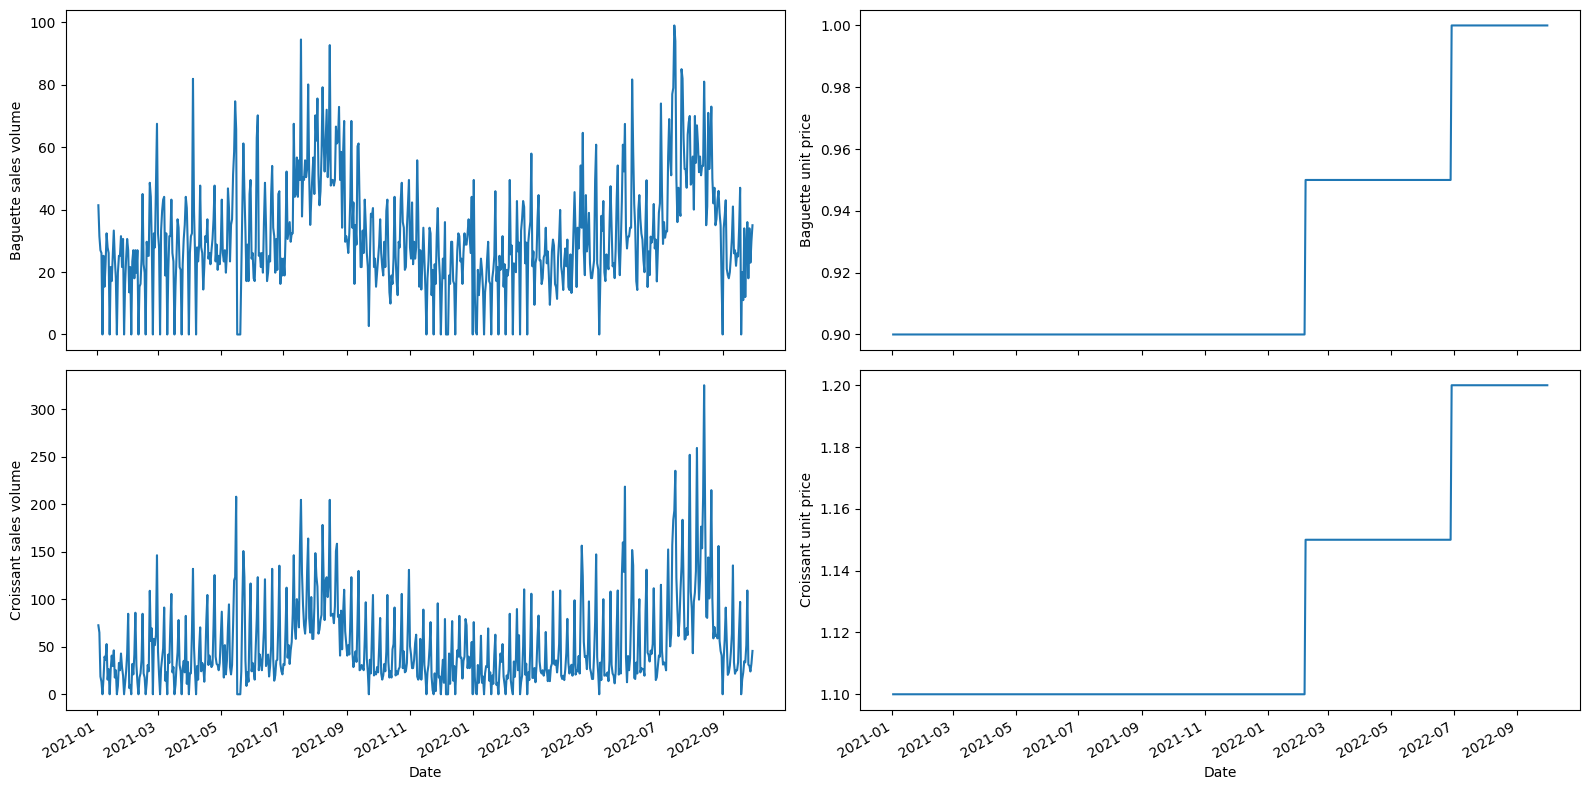

In [58]:
baguette_plot_df = df1[df1['unique_id'] == "BAGUETTE"]
croissant_plot_df = df1[df1['unique_id'] == "CROISSANT"]

fig, ((ax1, ax2), (ax3,ax4)) = plt.subplots(nrows = 2, ncols = 2,figsize = (16,8))

ax1.plot(baguette_plot_df['ds'],baguette_plot_df["y"])
ax1.set_xlabel('Date')
ax1.set_ylabel('Baguette sales volume')

ax2.plot(baguette_plot_df['ds'],baguette_plot_df["unit_price"])
ax2.set_xlabel('Date')
ax2.set_ylabel('Baguette unit price')

ax3.plot(croissant_plot_df['ds'],croissant_plot_df["y"])
ax3.set_xlabel('Date')
ax3.set_ylabel('Croissant sales volume')

ax4.plot(croissant_plot_df['ds'],croissant_plot_df["unit_price"])
ax4.set_xlabel('Date')
ax4.set_ylabel('Croissant unit price')

fig.autofmt_xdate()
plt.tight_layout()

In [59]:
unique_ids = ["BAGUETTE", "CROISSANT"]

small_df1 =  df1[df1["unique_id"].isin(unique_ids)]

test = small_df1.groupby("unique_id").tail(7)
train = small_df1.drop(test.index).reset_index(drop = True)

In [60]:
future_exog_df = test.groupby("unique_id").tail(horizon).drop(["y"], axis=1)
future_exog_df.head()

,unique_id,ds,unit_price
714,BAGUETTE,2022-09-24,1.0
715,BAGUETTE,2022-09-25,1.0
716,BAGUETTE,2022-09-26,1.0
717,BAGUETTE,2022-09-27,1.0
718,BAGUETTE,2022-09-28,1.0


In [61]:
#define model with exogenous features
models = [
    AutoARIMA(season_length= 7, alias = "SARIMA_exog")
]

sf = StatsForecast(models = models, freq = "D")
sf.fit(df = train)

arima_exog_preds = sf.predict( h = horizon, X_df=future_exog_df)

In [62]:
#normal sarima model
models = [
    AutoARIMA(season_length= 7, alias = "SARIMA")
]

sf = StatsForecast(models = models, freq = "D")
sf.fit(df = train.drop(["unit_price"],axis  =1))

arima_preds = sf.predict( h = horizon)

In [63]:
test_df = test.merge(arima_exog_preds, on =["unique_id", "ds"], how = "left")\
.merge(arima_preds, on =["unique_id", "ds"], how = "left")

test_df.head()

,unique_id,ds,y,unit_price,SARIMA_exog,SARIMA
0,BAGUETTE,2022-09-24,28.0,1.0,28.898898,28.657114
1,BAGUETTE,2022-09-25,36.0,1.0,42.513264,42.182373
2,BAGUETTE,2022-09-26,18.0,1.0,20.423976,20.013652
3,BAGUETTE,2022-09-27,34.0,1.0,19.066264,18.646490
4,BAGUETTE,2022-09-28,23.0,1.0,16.468885,16.114925


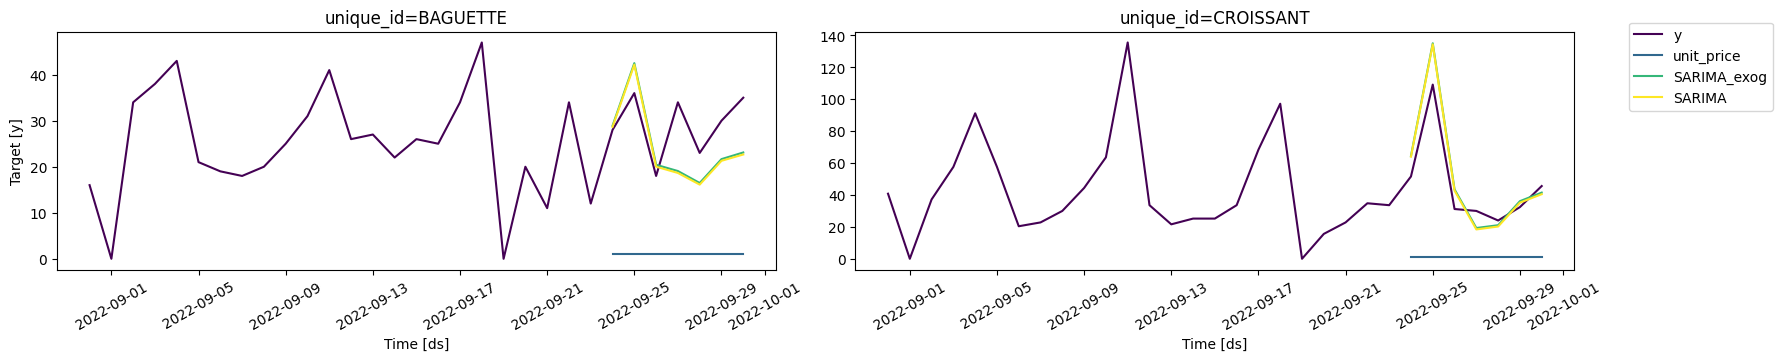

In [64]:
plot_series(
    df = train,
    forecasts_df= test_df,
    ids = ["BAGUETTE", "CROISSANT"],
    max_insample_length= 24,
    palette= "viridis"
    )

In [65]:
models = [
    AutoARIMA(season_length= 7, alias = "SARIMA_exog")
]

sf = StatsForecast(models = models,freq = "D")
cv_exog_df = sf.cross_validation(
    h = horizon,
    df = small_df1,
    n_windows = 8,
    step_size = horizon,
    refit = True
)

cv_exog_df.head()

,unique_id,ds,cutoff,y,SARIMA_exog
0,BAGUETTE,2022-08-06,2022-08-05,55.0,71.511528
1,BAGUETTE,2022-08-07,2022-08-05,67.0,78.458054
2,BAGUETTE,2022-08-08,2022-08-05,61.0,57.062745
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.525901
4,BAGUETTE,2022-08-10,2022-08-05,57.0,49.485683


In [66]:
cv_exog_eval = evaluate(
    cv_exog_df.drop(["cutoff"],axis=1),
    metrics = [mae],
)

cv_exog_eval = cv_exog_eval.drop(['unique_id'],axis = 1).groupby('metric').mean().reset_index()
cv_exog_eval

,metric,SARIMA_exog
0,mae,19.211687


###creating features from timestamps

In [67]:
from functools import partial
from utilsforecast.feature_engineering import fourier,time_features,pipeline

In [68]:
features = [
    partial(fourier,season_length = 7, k=2),
    partial(time_features,features = ["day","week","month"])
]

small_exog_df,future_exog_df = pipeline(
    df = small_df1,
    features= features,
    freq="D",
    h = horizon
)

In [69]:
small_exog_df.head()

,unique_id,ds,y,unit_price,sin1_7,sin2_7,cos1_7,cos2_7,day,week,month
84,BAGUETTE,2021-01-02,41.4,0.9,0.781832,0.974928,0.623490,-0.222521,2,53,1
85,BAGUETTE,2021-01-03,31.5,0.9,0.974928,-0.433884,-0.222521,-0.900969,3,53,1
86,BAGUETTE,2021-01-04,27.0,0.9,0.433884,-0.781831,-0.900969,0.623490,4,1,1
87,BAGUETTE,2021-01-05,26.1,0.9,-0.433884,0.781832,-0.900969,0.623490,5,1,1
88,BAGUETTE,2021-01-06,0.0,0.9,-0.974928,0.433884,-0.222521,-0.900969,6,1,1


In [70]:
future_exog_df.head()

,unique_id,ds,sin1_7,sin2_7,cos1_7,cos2_7,day,week,month
0,BAGUETTE,2022-10-01,0.781844,0.974919,0.623474,-0.222559,1,39,10
1,BAGUETTE,2022-10-02,0.974927,-0.433892,-0.222526,-0.900965,2,39,10
2,BAGUETTE,2022-10-03,0.433893,-0.781844,-0.900964,0.623474,3,40,10
3,BAGUETTE,2022-10-04,-0.433861,0.781800,-0.900980,0.623529,4,40,10
4,BAGUETTE,2022-10-05,-0.974933,0.433846,-0.222500,-0.900987,5,40,10


In [71]:
models = [
    AutoARIMA(season_length= 7, alias = "SARIMA_time_exog")
]

sf= StatsForecast(models = models,freq = "D")

In [72]:
cv_time_exog_df = sf.cross_validation(
    h = horizon,
    df = small_exog_df,
    n_windows = 8,
    step_size = horizon,
    refit = True
)

In [73]:
cv_time_exog_eval = evaluate(
    cv_time_exog_df.drop(["cutoff"],axis=1),
    metrics = [mae],
)

cv_time_exog_eval = cv_time_exog_eval.drop(['unique_id'],axis = 1).groupby('metric').mean().reset_index()
cv_time_exog_eval

,metric,SARIMA_time_exog
0,mae,19.721581


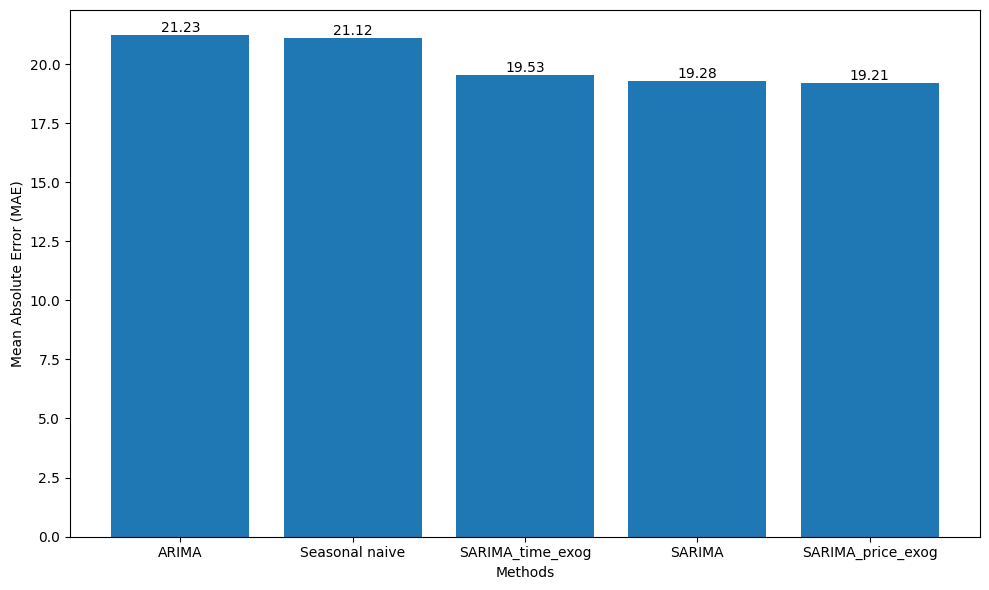

In [74]:
methods = ["ARIMA", "Seasonal naive", "SARIMA", "SARIMA_price_exog", "SARIMA_time_exog"]
values = [21.229, 21.118, 19.281, 19.210, 19.533]
sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse = True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted,values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.2f}', ha='center', va='bottom')

plt.xlabel('Methods')
plt.ylabel('Mean Absolute Error (MAE)')
plt.tight_layout()


###Prediction Interval with model

In [75]:
unique_ids = ["BAGUETTE", "CROISSANT"]
small_df1 =  df1[df1["unique_id"].isin(unique_ids)]

test = small_df1.groupby("unique_id").tail(7)
train = small_df1.drop(test.index).reset_index(drop = True)

In [76]:
train.head()

,unique_id,ds,y,unit_price
0,BAGUETTE,2021-01-02,41.4,0.9
1,BAGUETTE,2021-01-03,31.5,0.9
2,BAGUETTE,2021-01-04,27.0,0.9
3,BAGUETTE,2021-01-05,26.1,0.9
4,BAGUETTE,2021-01-06,0.0,0.9


In [77]:
models = [
    AutoARIMA(season_length= 7)
]

sf = StatsForecast(models = models, freq = "D")
sf.fit(df = train)

StatsForecast(models=[AutoARIMA])

In [78]:
prob_preds = sf.predict(h = horizon, X_df = test.drop(["y"], axis = 1), level = [80])

In [79]:
test_df = test.merge(prob_preds, on = ["unique_id","ds"], how = "left")

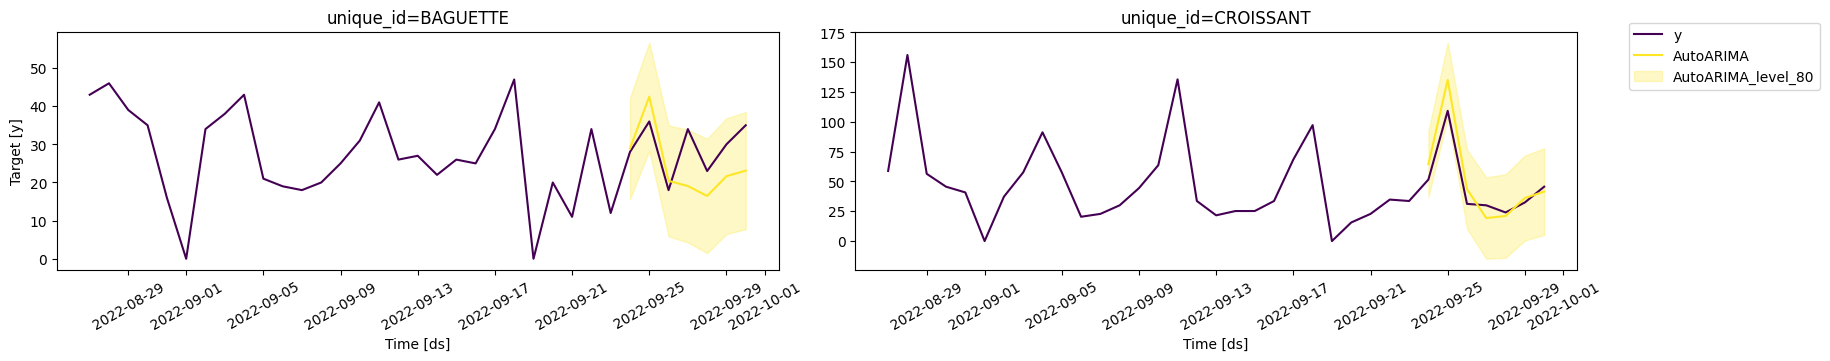

In [80]:
plot_series(
    df = train,
    forecasts_df= test_df,
    ids = ["BAGUETTE", "CROISSANT"],
    max_insample_length= 28,
    models= ["AutoARIMA"],
    level = [80],
    palette= "viridis"
    )

In [81]:
cv_prob_df = sf.cross_validation(
    h =horizon,
    df = small_df1,
    n_windows = 8,
    step_size = horizon,
    refit = True,
    level = [80]
)

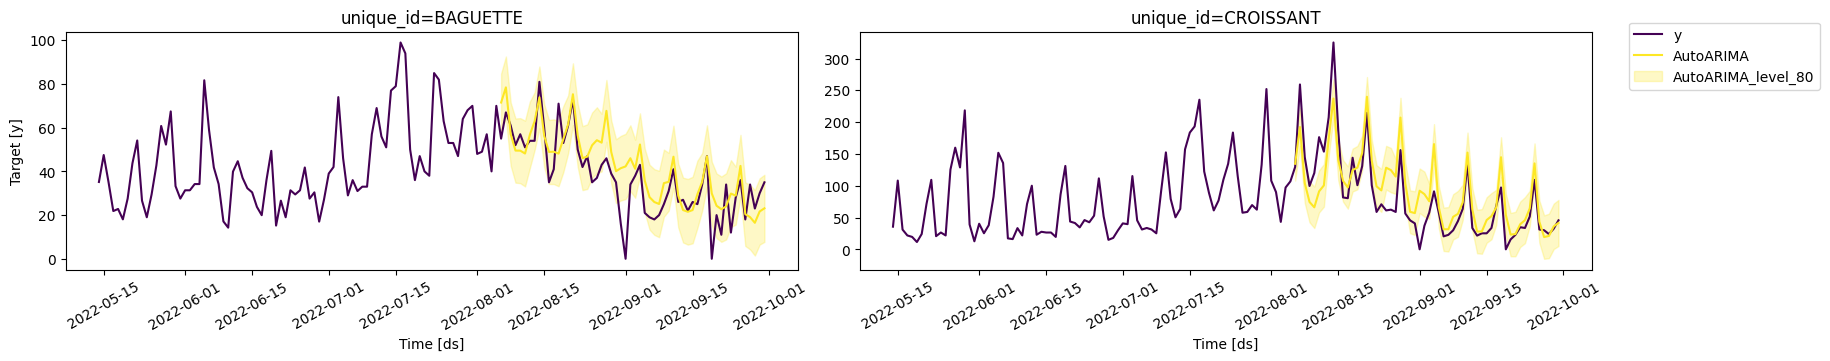

In [82]:
plot_series(
    df = small_df1,
    forecasts_df= cv_prob_df.drop(["y","cutoff"],axis=1),
    ids = ["BAGUETTE", "CROISSANT"],
    max_insample_length= 140,
    models= ["AutoARIMA"],
    level = [80],
    palette= "viridis"
    )